In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

I0000 00:00:1774884945.260850   12031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774884945.702566   12031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/jhebeler/workspace/.venv/lib/python3.12/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
            ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/jhebeler/workspace/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/jh

In [2]:
type(X)

numpy.ndarray

Epoch 1/20


/home/jhebeler/workspace/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774885124.182466   12031 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - Accuracy: 0.4688 - loss: 1.7458 - val_Accuracy: 0.2083 - val_loss: 2.3864
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - Accuracy: 0.4375 - loss: 1.6134 - val_Accuracy: 0.2083 - val_loss: 2.1382
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Accuracy: 0.3438 - loss: 1.6334 - val_Accuracy: 0.2083 - val_loss: 1.9074
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Accuracy: 0.4062 - loss: 1.4480 - val_Accuracy: 0.2083 - val_loss: 1.6732
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Accuracy: 0.4167 - loss: 1.2537 - val_Accuracy: 0.2083 - val_loss: 1.4715
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Accuracy: 0.3333 - loss: 1.2663 - val_Accuracy: 0.4583 - val_loss: 1.3105
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - Accuracy: 0.4375 - loss: 1.2271 - val_Accuracy: 0.5000 - val_loss: 1.1785
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - Accuracy: 0.4792 - loss: 1.1128 - val_Accuracy: 0.5000 - val_loss: 1.0899
Epoch 9/20

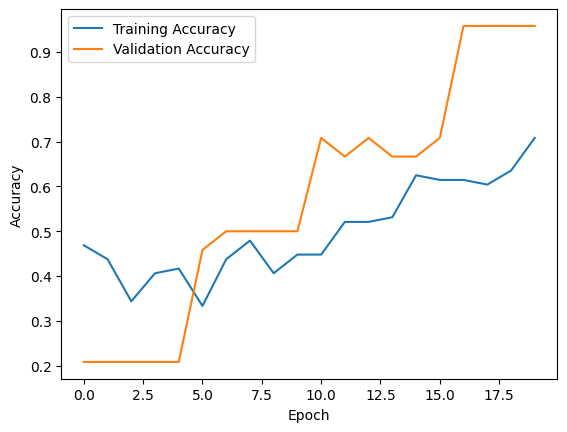

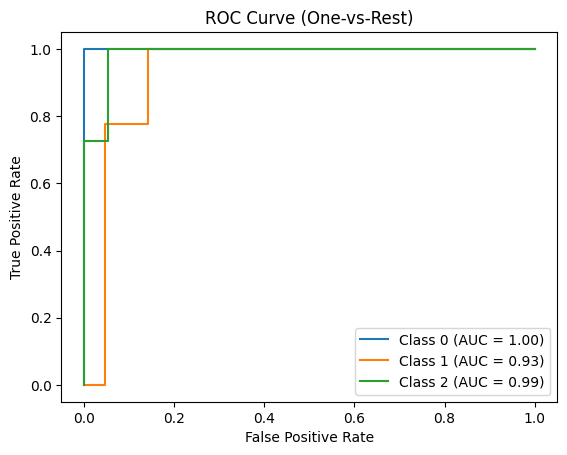

In [3]:
# Define the model (using softmax output)
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')  # Output layer with softmax for 3 classes
])

# Compile the model (CategoricalCrossentropy loss and metrics)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Important for multi-class with integer labels
              metrics=['Accuracy'])  # Only Accuracy here if labels are integers

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
y_pred_probs = model.predict(X_test) # Get probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Get predicted class labels

# Calculate metrics (using sklearn)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision (macro): {precision}")
print(f"Recall (macro): {recall}")
print(f"F1-score (macro): {f1}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

# --- ROC Curve ---
# For multi-class, we'll plot a ROC curve for each class (one-vs-rest)
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3  # Number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test, y_pred_probs[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])
    
plt.plot(history.history['Accuracy'], label='Training Accuracy')
plt.plot(history.history['val_Accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
    
# Plot the ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

#plt.plot(,, 'k--')  # Diagonal line for random chance
plt.xlim()
plt.ylim()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

# --- Other Plots ---
# (You can keep the previous accuracy plot as well)